In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data
from utils.random_forest import RF_data_prep

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)
# high_noise = final_clean_strained["Noise"].apply(lambda x: 1 if x > 0.9 else 0)
# high_noise.name = "HighNoise"
# final_clean_strained = pd.concat(
#     [final_clean_strained, peak_curvs, trough_curvs, high_noise], axis=1
# )

In [4]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [5]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = [
    "Frequency(kHz)",
    "Amplitude",
    "Slope",
    "Total Variance",
    "Distance",
    "Noise",
    "Time (hrs)",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
    "Level(dB)",
]
cat_features = ["vx", "Strain (binary)"]
# cat_features = ["vx", "Strain (binary)", "HighNoise"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features
)

# Vanilla Linear Regression

In [6]:
smf_df = final_clean_strained_70.copy()
smf_df.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "vx",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Slope",
    "TotalVariance",
    "Distance",
    "PeakICurvature",
    "TroughICurvature",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    # "HighNoise",
    "DataGroup",
]

In [7]:
import statsmodels.formula.api as smf

model_text = "SynapsesPerIHC ~ C(vx) + C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Noise",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     38.51
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           3.51e-92
Time:                        16:00:18   Log-Likelihood:                -3119.1
No. Observations:                1268   AIC:                             6270.
Df Residuals:                    1252   BIC:                             6352.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  16.3941      0.602     27.254      0.000      15.214      17.574
C(vx)[T.v2]                 0.0346      0.160      0.216      0.829      -0.279       0.349
C(Strain_b)[T.1]            1.3694      0.232      5.906      0.000       0.915       1.824
Frequency                  -0.0246      0.007     -3.590      0.000      -0.038      -0.011
Amplitude                   2.1195      0.718      2.951      0.003       0.711       3.528
Slope                      -0.1079      0.198     -0.546      0.585      -0.496       0.280
TotalVariance              -0.2813      0.071     -3.968      0.000      -0.420      -0.142
Distance                   -1.1769      0.398     -2.955      0.003      -1.958      -0.395
Noise                      -2.4504      0.260     -9.428      0.000      -2.960      -1.941
Time_hrs                   -0.0159      0.004     -4.487      0.000      -0.023      -0.009
PeakILeftCurvature         -0.0029      0.011     -0.264      0.792      -0.025       0.019
PeakIOverallCurvature      -0.0016      0.003     -0.458      0.647      -0.008       0.005
PeakIRightCurvature        -0.0858      0.012     -7.123      0.000      -0.109      -0.062
TroughILeftCurvature       -0.0200      0.008     -2.378      0.018      -0.037      -0.004
TroughIOverallCurvature    -0.0017      0.003     -0.498      0.619      -0.008       0.005
TroughIRightCurvature      -0.0029      0.006     -0.447      0.655      -0.015       0.010
==============================================================================
Omnibus:                       69.208   Durbin-Watson:                   1.141
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               94.787
Skew:                          -0.489   Prob(JB):                     2.61e-21
Kurtosis:                       3.915   Cond. No.                         710.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Linear Regression w/ Interaction Terms

In [8]:
model_text = "SynapsesPerIHC ~ C(vx) + C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + Noise:{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     49.49
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          3.05e-109
Time:                        16:00:18   Log-Likelihood:                -3080.5
No. Observations:                1268   AIC:                             6191.
Df Residuals:                    1253   BIC:                             6268.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        15.0343      0.246     61.079      0.000      14.551      15.517
C(vx)[T.v2]                       0.0344      0.155      0.222      0.825      -0.270       0.339
C(Strain_b)[T.1]                  1.5609      0.220      7.080      0.000       1.128       1.993
Noise:Frequency                  -0.0613      0.008     -7.964      0.000      -0.076      -0.046
Noise:Amplitude                   1.5023      0.822      1.827      0.068      -0.111       3.115
Noise:Slope                      -0.4210      0.267     -1.576      0.115      -0.945       0.103
Noise:TotalVariance              -0.3202      0.075     -4.253      0.000      -0.468      -0.173
Noise:Distance                   -1.3056      0.375     -3.481      0.001      -2.041      -0.570
Noise:Time_hrs                   -0.0200      0.004     -4.452      0.000      -0.029      -0.011
Noise:PeakILeftCurvature          0.0010      0.012      0.089      0.929      -0.022       0.024
Noise:PeakIOverallCurvature      -0.0032      0.004     -0.708      0.479      -0.012       0.006
Noise:PeakIRightCurvature        -0.1030      0.013     -7.858      0.000      -0.129      -0.077
Noise:TroughILeftCurvature       -0.0331      0.009     -3.585      0.000      -0.051      -0.015
Noise:TroughIOverallCurvature    -0.0054      0.004     -1.210      0.227      -0.014       0.003
Noise:TroughIRightCurvature       0.0101      0.008      1.204      0.229      -0.006       0.027
==============================================================================
Omnibus:                       64.899   Durbin-Watson:                   1.156
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.520
Skew:                          -0.431   Prob(JB):                     4.04e-22
Kurtosis:                       4.059   Cond. No.                         533.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
model_text = "SynapsesPerIHC ~ C(vx) + C(Strain_b)"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + Noise*{feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     26.65
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          1.22e-103
Time:                        16:00:18   Log-Likelihood:                -3069.4
No. Observations:                1268   AIC:                             6195.
Df Residuals:                    1240   BIC:                             6339.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        12.1145      1.402      8.639      0.000       9.363      14.866
C(vx)[T.v2]                       0.0344      0.155      0.222      0.824      -0.269       0.338
C(Strain_b)[T.1]                  1.4852      0.228      6.508      0.000       1.037       1.933
Noise                             2.7690      1.521      1.821      0.069      -0.215       5.752
Frequency                         0.0266      0.011      2.343      0.019       0.004       0.049
Noise:Frequency                  -0.0865      0.015     -5.809      0.000      -0.116      -0.057
Amplitude                         1.5414      1.392      1.107      0.268      -1.189       4.272
Noise:Amplitude                   0.1302      1.726      0.075      0.940      -3.256       3.517
Slope                            -0.2291      0.326     -0.703      0.482      -0.868       0.410
Noise:Slope                      -0.1921      0.434     -0.442      0.658      -1.044       0.660
TotalVariance                    -0.2020      0.137     -1.480      0.139      -0.470       0.066
Noise:TotalVariance              -0.1386      0.170     -0.814      0.416      -0.472       0.195
Distance                          4.1690      2.258      1.846      0.065      -0.262       8.600
Noise:Distance                   -5.5233      2.390     -2.311      0.021     -10.211      -0.835
Time_hrs                         -0.0170      0.006     -2.820      0.005      -0.029      -0.005
Noise:Time_hrs                   -0.0020      0.008     -0.254      0.800      -0.017       0.013
PeakILeftCurvature                0.0223      0.028      0.796      0.426      -0.033       0.077
Noise:PeakILeftCurvature         -0.0194      0.032     -0.614      0.539      -0.081       0.043
PeakIOverallCurvature             0.0016      0.005      0.299      0.765      -0.009       0.012
Noise:PeakIOverallCurvature      -0.0045      0.007     -0.623      0.533      -0.019       0.010
PeakIRightCurvature               0.0086      0.031      0.282      0.778      -0.052       0.069
Noise:PeakIRightCurvature        -0.1098      0.035     -3.163      0.002      -0.178      -0.042
TroughILeftCurvature              0.0238      0.022      1.098      0.272      -0.019       0.066
Noise:TroughILeftCurvature       -0.0566      0.025     -2.284      0.023      -0.105      -0.008
TroughIOverallCurvature           0.0006      0.005      0.118      0.906      -0.009       0.011
Noise:TroughIOverallCurvature    -0.0057      0.007     -0.814      0.416      -0.019       0.008
TroughIRightCurvature            -0.0020      0.010     -0.202      0.840      -0.022       0.018
Noise:TroughIRightCurvature       0.0128      0.014      0.948      0.343      -0.014       0.039
=============================================

In [10]:
model_text = "SynapsesPerIHC ~ C(vx) + C(Strain_b) + Noise:Frequency"
for feature in [
    "Frequency",
    "Amplitude",
    "Slope",
    "Noise",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     40.89
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          2.41e-102
Time:                        16:00:18   Log-Likelihood:                -3092.9
No. Observations:                1268   AIC:                             6220.
Df Residuals:                    1251   BIC:                             6307.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  15.1661      0.613     24.731      0.000      13.963      16.369
C(vx)[T.v2]                 0.0354      0.157      0.226      0.821      -0.272       0.343
C(Strain_b)[T.1]            1.3322      0.227      5.861      0.000       0.886       1.778
Noise:Frequency            -0.1031      0.014     -7.263      0.000      -0.131      -0.075
Frequency                   0.0383      0.011      3.495      0.000       0.017       0.060
Amplitude                   1.8387      0.705      2.609      0.009       0.456       3.221
Slope                      -0.1325      0.194     -0.684      0.494      -0.513       0.248
Noise                      -0.2070      0.400     -0.517      0.605      -0.992       0.578
TotalVariance              -0.2628      0.070     -3.781      0.000      -0.399      -0.126
Distance                   -1.0721      0.391     -2.744      0.006      -1.838      -0.306
Time_hrs                   -0.0160      0.003     -4.615      0.000      -0.023      -0.009
PeakILeftCurvature          0.0013      0.011      0.117      0.907      -0.020       0.023
PeakIOverallCurvature      -0.0018      0.003     -0.526      0.599      -0.008       0.005
PeakIRightCurvature        -0.0847      0.012     -7.174      0.000      -0.108      -0.062
TroughILeftCurvature       -0.0212      0.008     -2.574      0.010      -0.037      -0.005
TroughIOverallCurvature    -0.0031      0.003     -0.953      0.341      -0.010       0.003
TroughIRightCurvature      -0.0004      0.006     -0.058      0.954      -0.013       0.012
==============================================================================
Omnibus:                       66.384   Durbin-Watson:                   1.142
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               97.467
Skew:                          -0.450   Prob(JB):                     6.84e-22
Kurtosis:                       4.017   Cond. No.                         725.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Elastic Net

In [11]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Elastic Net training set score: {pipeline.score(X_train, y_train)}")
print(f"Elastic Net test set score: {pipeline.score(X_test, y_test)}")

Elastic Net training set score: 0.29336997125061226
Elastic Net test set score: 0.3553340148031655


# Random Forest

In [12]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 50, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 5}
Best RF score: 0.444, R2 on test set: 0.684


In [13]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [14]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    num_features = [
        "Frequency(kHz)",
        "Amplitude",
        "Slope",
        "Total Variance",
        "Distance",
        "Noise",
        "Time (hrs)",
        "Level(dB)",
        "PeakI Left Curvature",
        "PeakI Overall Curvature",
        "PeakI Right Curvature",
        "TroughI Left Curvature",
        "TroughI Overall Curvature",
        "TroughI Right Curvature",
    ]
    cat_features = ["Strain (binary)"]
    if len(df["vx"]) > 1:
        cat_features.append("vx")
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features
        data = df[(df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10)]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

In [15]:
# train_plot_result(final_clean_strained, best_rf_model)3

# Feature Importance

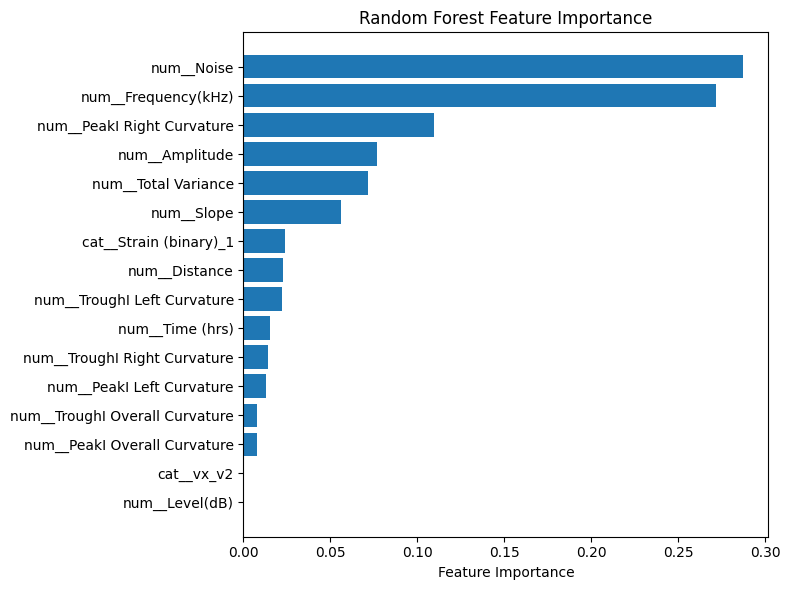

In [16]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                           Feature  Importance_Mean  Importance_Std
5                       num__Noise         0.523441        0.042220
0              num__Frequency(kHz)         0.466603        0.053241
1                   num__Amplitude         0.059269        0.005936
9       num__PeakI Right Curvature         0.044951        0.006456
3              num__Total Variance         0.040337        0.004163
2                       num__Slope         0.031524        0.006055
7        num__PeakI Left Curvature         0.009918        0.001346
10     num__TroughI Left Curvature         0.008345        0.001529
15          cat__Strain (binary)_1         0.008276        0.003620
6                  num__Time (hrs)         0.007682        0.002215
4                    num__Distance         0.006721        0.001795
14                      cat__vx_v2         0.000006        0.000010
13                  num__Level(dB)         0.000000        0.000000
12    num__Tro

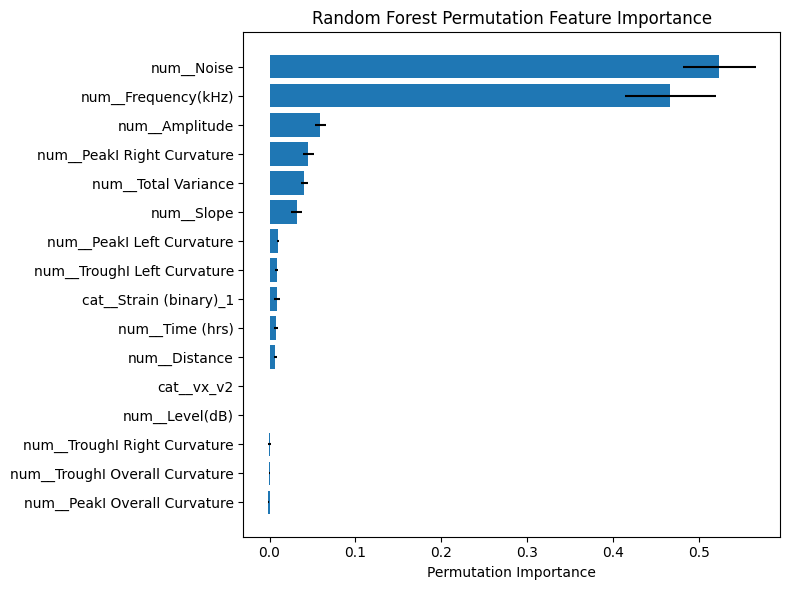

In [17]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df["Importance_Mean"],
    xerr=perm_importance_df["Importance_Std"],
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df["Feature"])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP

[Text(0, 0, 'num__Level(dB)'), Text(0, 1, 'cat__vx_v2'), Text(0, 2, 'num__PeakI Overall Curvature'), Text(0, 3, 'num__TroughI Overall Curvature'), Text(0, 4, 'num__PeakI Left Curvature'), Text(0, 5, 'num__Distance'), Text(0, 6, 'num__TroughI Right Curvature'), Text(0, 7, 'num__Time (hrs)'), Text(0, 8, 'num__TroughI Left Curvature'), Text(0, 9, 'cat__Strain (binary)_1'), Text(0, 10, 'num__Slope'), Text(0, 11, 'num__Total Variance'), Text(0, 12, 'num__Amplitude'), Text(0, 13, 'num__PeakI Right Curvature'), Text(0, 14, 'num__Frequency(kHz)'), Text(0, 15, 'num__Noise')]


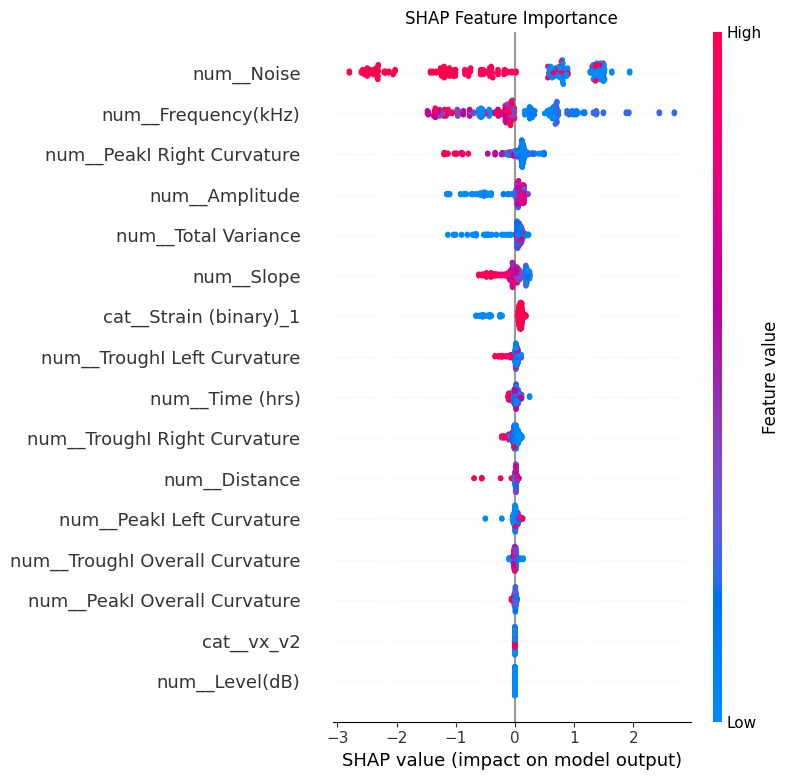

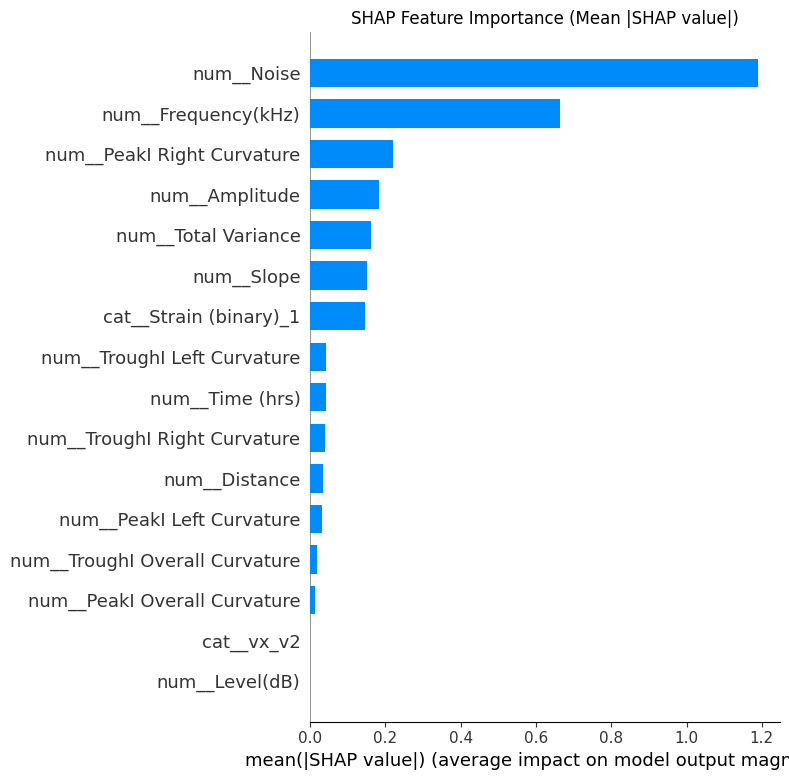

In [18]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["rf"])

# Get preprocessed test data
X_test_preprocessed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_preprocessed)

# Summary plot
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values, X_test_preprocessed, feature_names=feature_names, show=False
)
plt.title("SHAP Feature Importance")
print(plt.gca().get_yticklabels())
# plt.gca().set_yticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

In [19]:
shap_interaction_values = explainer.shap_interaction_values(X_test_preprocessed)

In [20]:
def plot_shap_dependence(ft1, ft2):
    top_features = importance_df["Feature"].values
    feature_idx1 = list(feature_names).index(top_features[ft1])
    feature_idx2 = list(feature_names).index(top_features[ft2])

    # Main effects and interaction using shap.dependence_plot
    shap.dependence_plot(
        feature_idx1,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft1]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        feature_idx2,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft2]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        (feature_idx1, feature_idx2),
        shap_interaction_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
        interaction_index=feature_idx2,
    )
    plt.title(f"{top_features[ft1]} x {top_features[ft2]} Interaction")

    plt.tight_layout()
    plt.show()

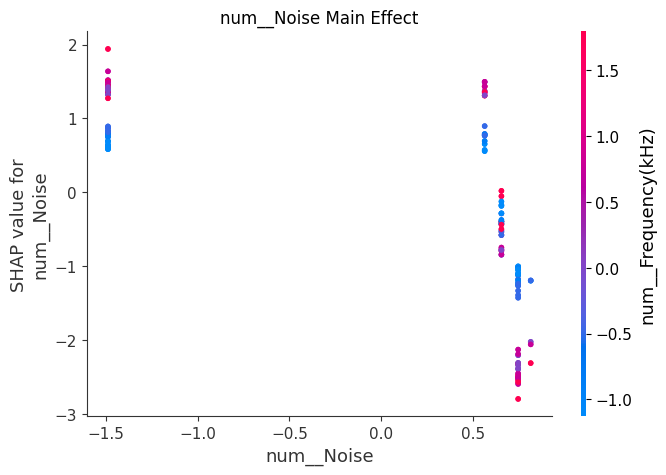

<Figure size 300x300 with 0 Axes>

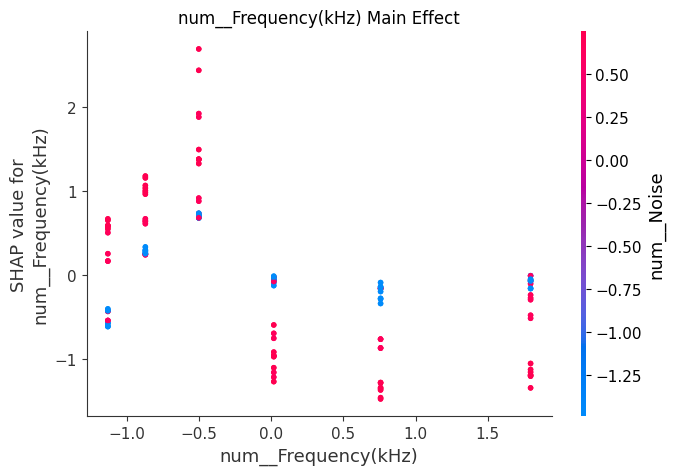

<Figure size 300x300 with 0 Axes>

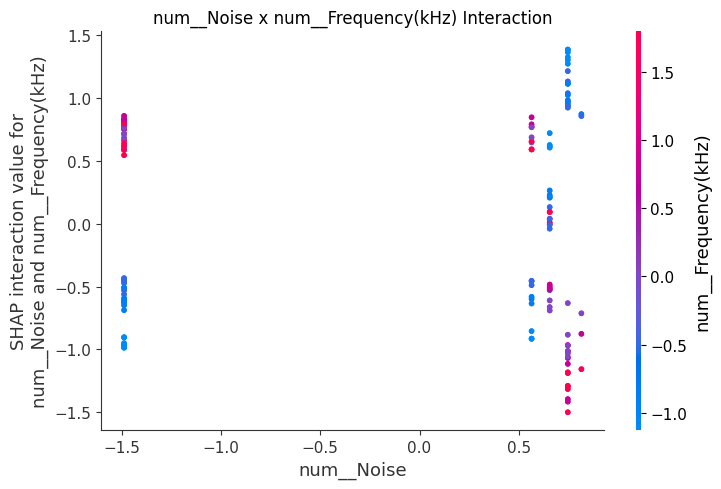

In [21]:
plot_shap_dependence(0, 1)

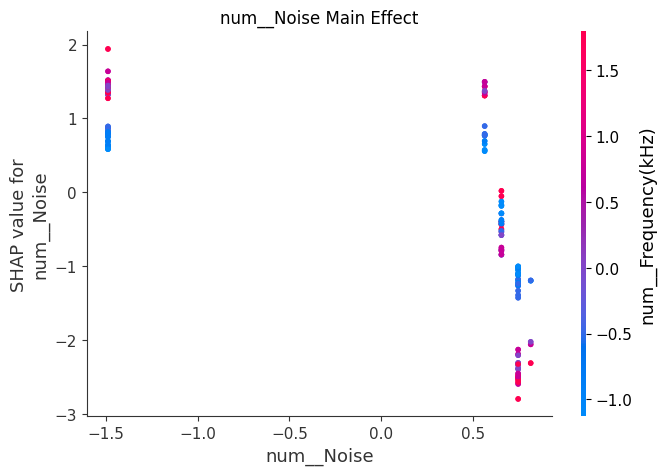

<Figure size 300x300 with 0 Axes>

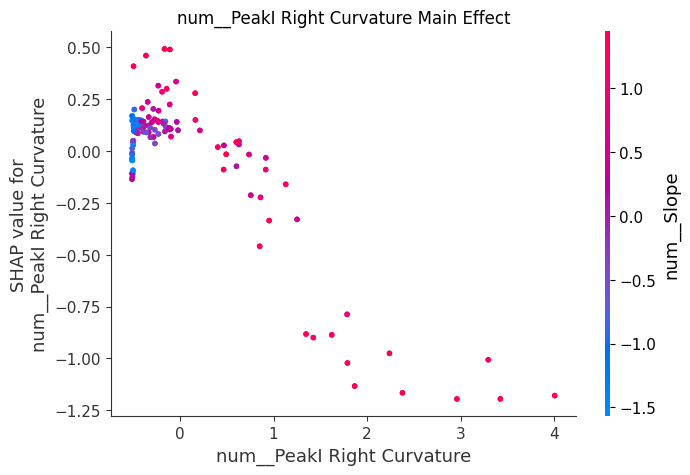

<Figure size 300x300 with 0 Axes>

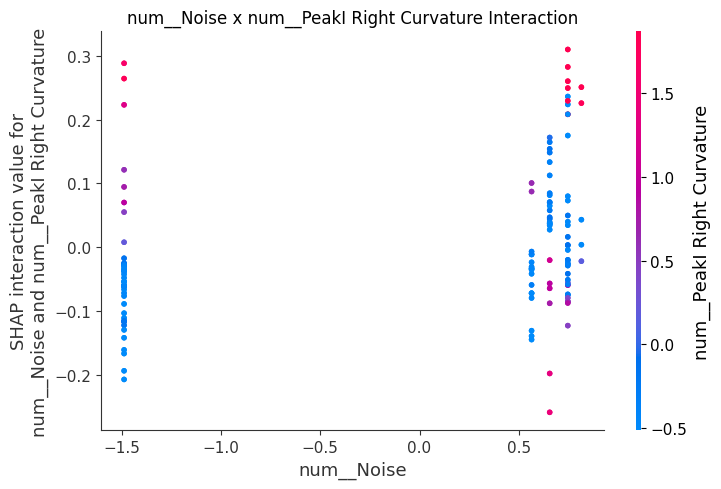

In [22]:
plot_shap_dependence(0, 2)

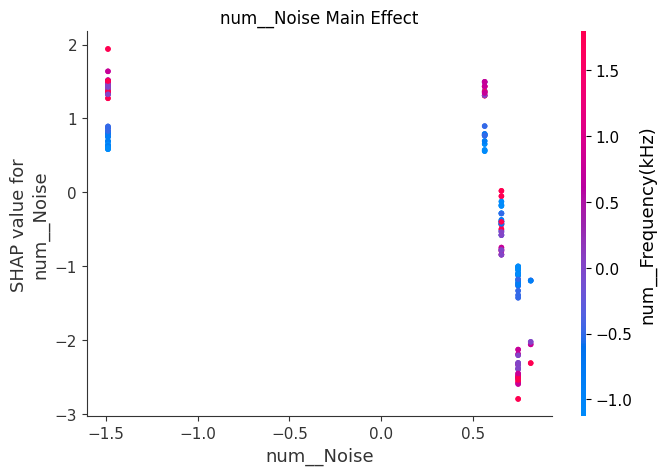

<Figure size 300x300 with 0 Axes>

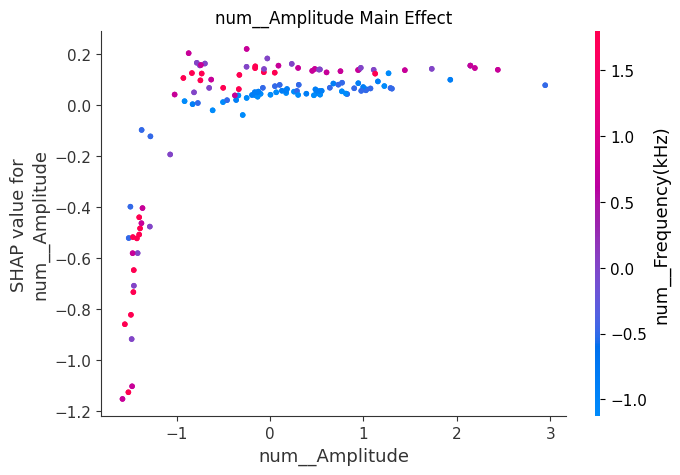

<Figure size 300x300 with 0 Axes>

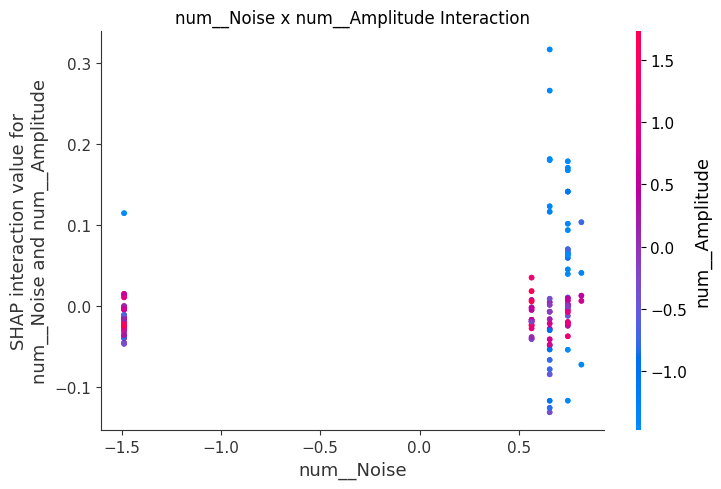

In [23]:
plot_shap_dependence(0, 3)

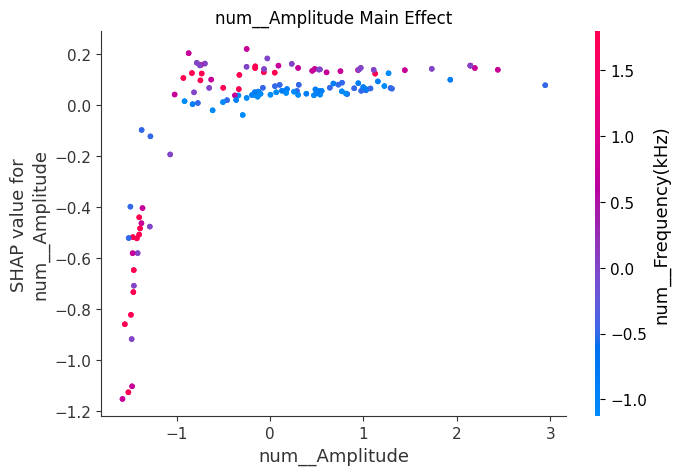

<Figure size 300x300 with 0 Axes>

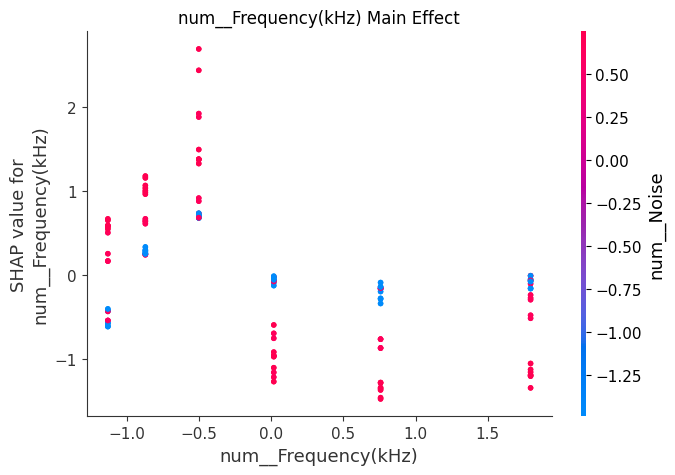

<Figure size 300x300 with 0 Axes>

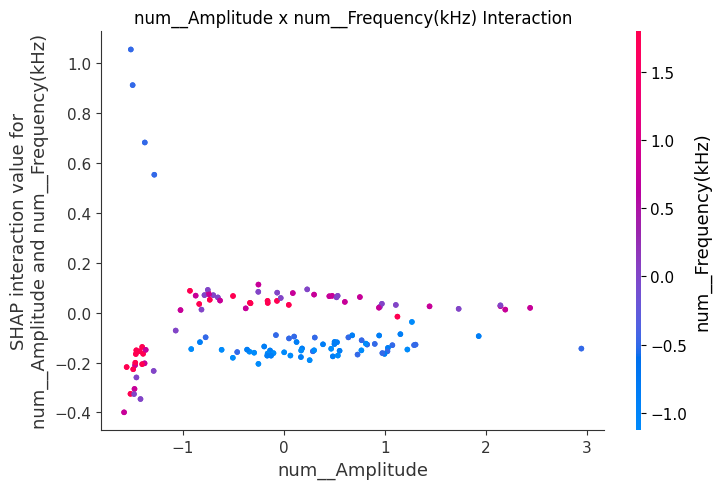

In [24]:
plot_shap_dependence(3, 1)

Best RF score: 0.774, R2 on test set: 0.675
10-15 dB, 1126 samples, R2: 0.305, RMSE: 2.017
20-25 dB, 1796 samples, R2: 0.386, RMSE: 1.829
30-35 dB, 1868 samples, R2: 0.443, RMSE: 1.937
40-45 dB, 1653 samples, R2: 0.429, RMSE: 2.085
50-55 dB, 1496 samples, R2: 0.537, RMSE: 2.211
60-65 dB, 1488 samples, R2: 0.639, RMSE: 2.302
70-75 dB, 1492 samples, R2: 0.736, RMSE: 2.091
80-85 dB, 1268 samples, R2: 0.665, RMSE: 2.104
All data, 12187 samples, R2: 0.671, RMSE: 1.854


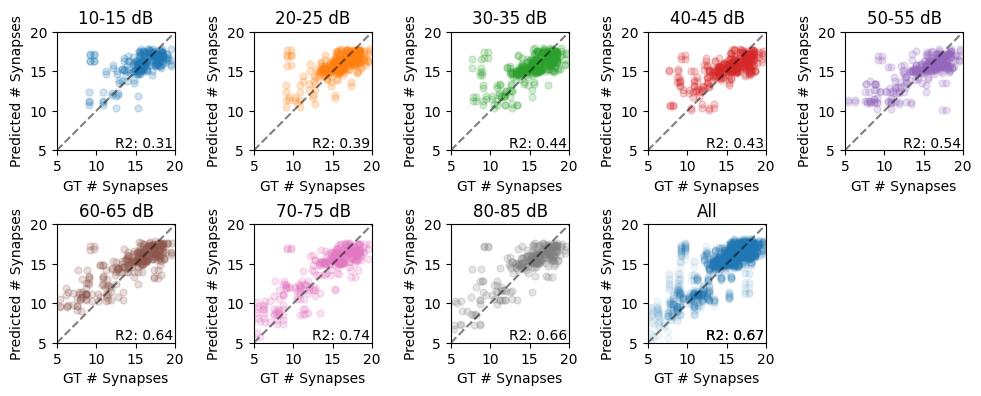

In [25]:
# Deeper trees
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)